# Problema del Paracaidista

## Ecuación de movimiento

Aplicando la segunda ley de Newton:

$$
m\frac{dv}{dt} = mg - kv
$$

o

$$
\frac{dv}{dt} = g - \frac{k}{m}v
$$

---

## Ecuación de posición

La altura disminuye mientras cae:

$$
\frac{dx}{dt} = -v
$$

con condiciones iniciales:

$$
v(0)=0, \quad x(0)=h_0
$$

---

## Método numérico

Se usa el método de Euler:

$$
v_{n+1}=v_n+\Delta t\left(g-\frac{k}{m}v_n\right)
$$

$$
x_{n+1}=x_n-\Delta t\,v_n
$$

Tiempo de impacto: 70.20 s
Velocidad al impactar: 62.78 m/s

Archivo guardado como: teorico.dat


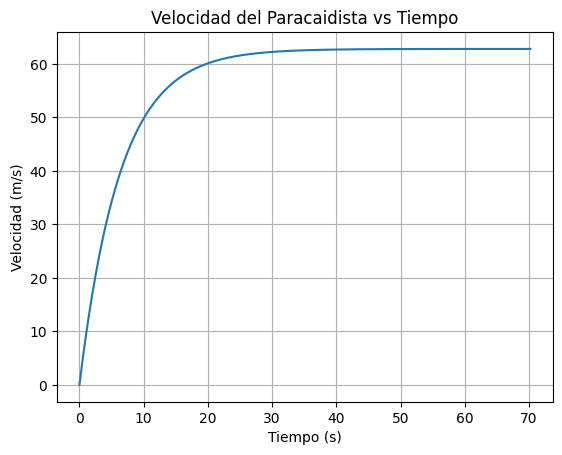

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Parámetros físicos
# -----------------------------
m = 80.0        # masa (kg)
g = 9.81        # gravedad (m/s^2)
k = 12.5        # coeficiente de arrastre
h0 = 4000.0     # altura inicial (m)

# -----------------------------
# Parámetros numéricos
# -----------------------------
dt = 0.1

# Listas dinámicas (ya no usamos tiempo fijo)
t = [0.0]
v = [0.0]       # velocidad positiva hacia abajo
x = [h0]        # altura

# -----------------------------
# Método de Euler
# -----------------------------
while x[-1] > 0:

    dvdt = g - (k/m)*v[-1]
    dxdt = -v[-1]

    v_new = v[-1] + dvdt*dt
    x_new = x[-1] + dxdt*dt
    t_new = t[-1] + dt

    v.append(v_new)
    x.append(x_new)
    t.append(t_new)

# Convertir a arrays
t = np.array(t)
x = np.array(x)
v = np.array(v)

print(f"Tiempo de impacto: {t[-1]:.2f} s")
print(f"Velocidad al impactar: {v[-1]:.2f} m/s")

# -----------------------------
# Guardar archivo .dat alineado
# -----------------------------
nombre_archivo = "teorico.dat"

with open(nombre_archivo, "w") as f:

    f.write(f"{'Tiempo (s)':>15} {'Altura (m)':>20} {'Velocidad (m/s)':>20}\n")

    for ti, xi, vi in zip(t, x, v):
        f.write(f"{ti:15.5f} {xi:20.8f} {vi:20.8f}\n")

print(f"\nArchivo guardado como: {nombre_archivo}")

# -----------------------------
# Gráfica velocidad
# -----------------------------
plt.figure()
plt.plot(t, v)
plt.xlabel("Tiempo (s)")
plt.ylabel("Velocidad (m/s)")
plt.title("Velocidad del Paracaidista vs Tiempo")
plt.grid()
plt.show()

## Entrenamiento de Redes Neuronales para Regresión

A continuación, utilizaremos los datos generados anteriormente para entrenar tres arquitecturas de redes neuronales distintas. El objetivo es predecir la **velocidad ($v$)** en función del **tiempo ($t$)**.

Pasos que realizaremos:
1. Preparación y normalización de los datos.
2. Definición de 3 arquitecturas (2, 3 y 4 capas).
3. Entrenamiento midiendo el tiempo de ejecución de cada una.
4. Visualización de resultados y comparativa de rendimiento.

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# 1. Preparación de datos (usando las variables t y v de tu celda anterior)
# Reajustamos la forma para que Keras los procese (matrices columna)
X = t.reshape(-1, 1)
y = v.reshape(-1, 1)

# Normalización: Es vital para que la red converja rápido
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# División en entrenamiento y validación
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

print(f"Datos preparados. Formato de entrada: {X_train.shape}")

Datos preparados. Formato de entrada: (562, 1)


Arquitectura de 2 capas:  Capa de entrada, 2 capas ocultas de 16 neuronas cada una y una caa de salida.
    (Puede sufrir underfitting)

Arquitectura de 3 capas:  3 capas ocultas, la primera de 64, la segunda de 32 y la tercera de 16.

Arquitectua de 4 capas: 4 capas ocultas, la primera de 128, la segunda de 64, la tercera de 32 y la ultima de 16 


El entrenemiento due 80 - 20

In [5]:
# Definición de las 3 arquitecturas solicitadas
def obtener_modelos():
    # Arquitectura 1: 2 capas ocultas (Pequeña)
    m1 = keras.Sequential([
        layers.Dense(16, activation='relu', input_shape=(1,)),
        layers.Dense(16, activation='relu'),
        layers.Dense(1) # Salida lineal para regresión
    ])
    
    # Arquitectura 2: 3 capas ocultas (Mediana)
    m2 = keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=(1,)),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1)
    ])
    
    # Arquitectura 3: 4 capas ocultas (Grande/Profunda)
    m3 = keras.Sequential([
        layers.Dense(128, activation='relu', input_shape=(1,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1)
    ])
    
    modelos = [m1, m2, m3]
    nombres = ["2 Capas (Pequeña)", "3 Capas (Mediana)", "4 Capas (Grande)"]
    
    for m in modelos:
        m.compile(optimizer='adam', loss='mse', metrics=['mae'])
        
    return modelos, nombres

modelos, nombres = obtener_modelos()
historiales = []
tiempos = []

# Proceso de entrenamiento y medición de tiempo
for i in range(len(modelos)):
    print(f"Entrenando {nombres[i]}...")
    
    inicio = time.time()
    history = modelos[i].fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        verbose=0 # No mostramos logs para limpiar la salida
    )
    fin = time.time()
    
    duracion = fin - inicio
    tiempos.append(duracion)
    historiales.append(history)
    print(f"Completado en {duracion:.2f} segundos.")

print("\n--- Entrenamiento finalizado ---")

/home/sergio/Documentos/Tarea REdes Neuronales/tf_gpu/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1772598354.271304   20213 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13007 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Ti, pci bus id: 0000:07:00.0, compute capability: 8.9


Entrenando 2 Capas (Pequeña)...


2026-03-03 23:25:55.402906: I external/local_xla/xla/service/service.cc:163] XLA service 0x7d0c88007500 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-03 23:25:55.402916: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Ti, Compute Capability 8.9
2026-03-03 23:25:55.417207: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-03 23:25:55.497388: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
I0000 00:00:1772598355.893210   21441 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Completado en 8.85 segundos.
Entrenando 3 Capas (Mediana)...
Completado en 9.81 segundos.
Entrenando 4 Capas (Grande)...


2026-03-03 23:26:14.571405: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-03 23:26:14.571453: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-03 23:26:15.385784: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_410', 8 bytes spill stores, 8 bytes spill loads

2026-03-03 23:26:15.390917: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Re

Completado en 12.02 segundos.

--- Entrenamiento finalizado ---


## Resultados y Comparativa

Analizaremos el desempeño mediante dos gráficas:
1. **Curvas de Error (Loss):** Para ver qué tan rápido aprendió cada red.
2. **Tiempos de Ejecución:** Para comparar el costo computacional de cada arquitectura.

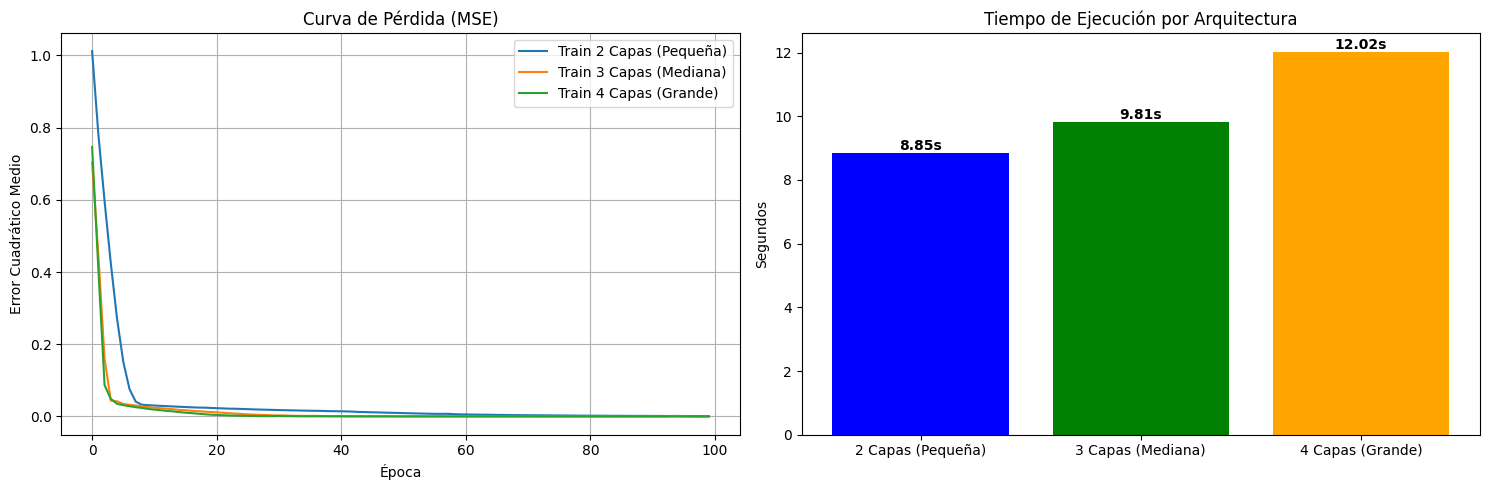

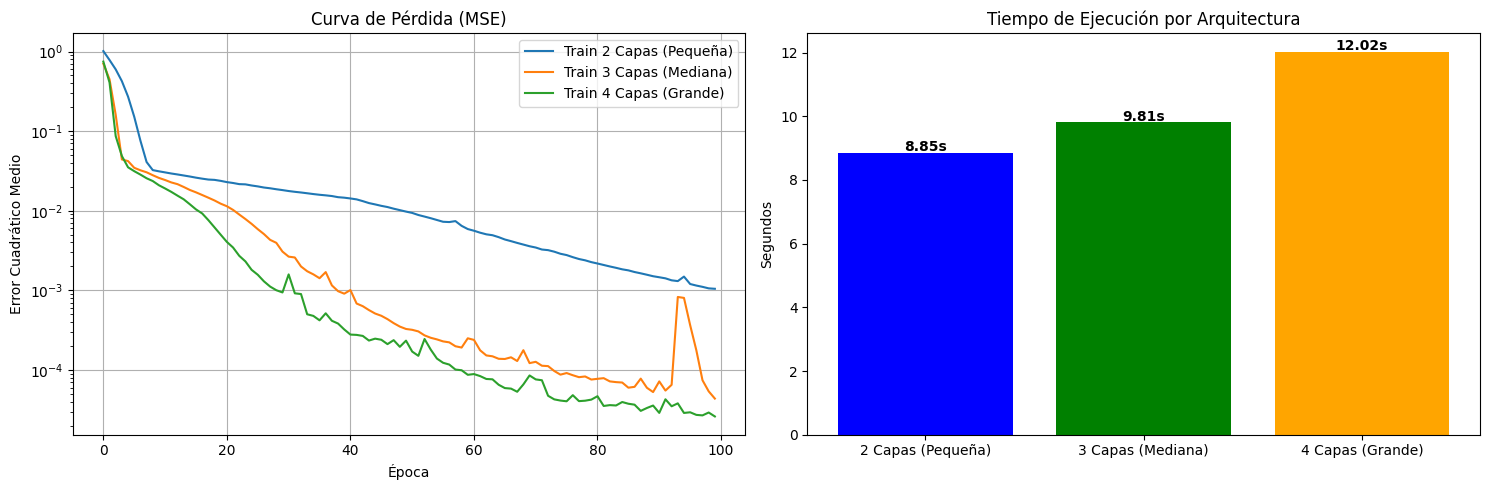

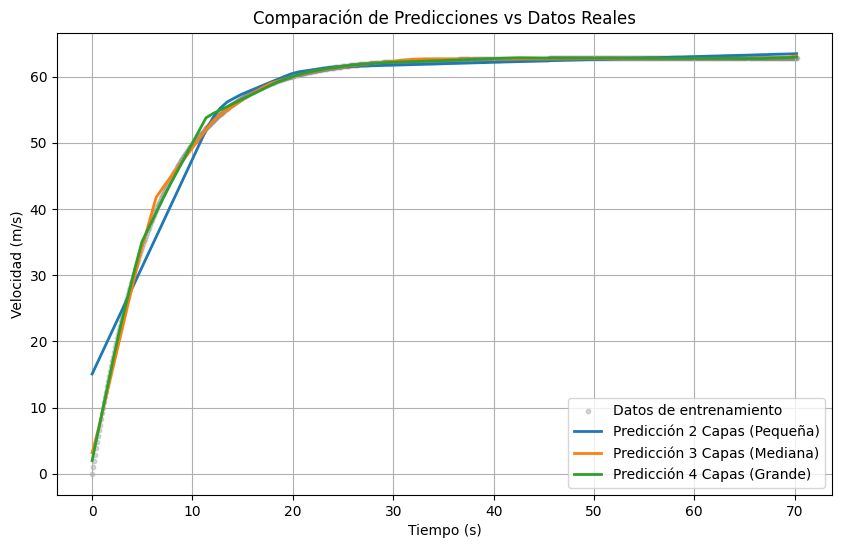

In [7]:
# Configuración de las gráficas
plt.figure(figsize=(15, 5))

# Gráfica 1: Pérdida (MSE) durante el entrenamiento
plt.subplot(1, 2, 1)
for i in range(len(historiales)):
    plt.plot(historiales[i].history['loss'], label=f'Train {nombres[i]}')
plt.title('Curva de Pérdida (MSE)')
plt.xlabel('Época')
plt.ylabel('Error Cuadrático Medio')
plt.legend()
plt.grid(True)

# Gráfica 2: Tiempos de ejecución
plt.subplot(1, 2, 2)
plt.bar(nombres, tiempos, color=['blue', 'green', 'orange'])
plt.title('Tiempo de Ejecución por Arquitectura')
plt.ylabel('Segundos')
for i, v in enumerate(tiempos):
    plt.text(i, v + 0.1, f"{v:.2f}s", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Configuración de las gráficas
plt.figure(figsize=(15, 5))

# Gráfica 1: Pérdida (MSE) durante el entrenamiento
plt.subplot(1, 2, 1)
for i in range(len(historiales)):
    plt.plot(historiales[i].history['loss'], label=f'Train {nombres[i]}')
plt.title('Curva de Pérdida (MSE)')
plt.xlabel('Época')
plt.ylabel('Error Cuadrático Medio')
plt.yscale('log') # Escala logarítmica para ver mejor la diferencia
plt.legend()
plt.grid(True)

# Gráfica 2: Tiempos de ejecución
plt.subplot(1, 2, 2)
plt.bar(nombres, tiempos, color=['blue', 'green', 'orange'])
plt.title('Tiempo de Ejecución por Arquitectura')
plt.ylabel('Segundos')
for i, v_val in enumerate(tiempos):
    plt.text(i, v_val + 0.05, f"{v_val:.2f}s", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# --- CORRECCIÓN DEL ERROR DE DIMENSIONES ---
# Aseguramos que usamos los mismos datos que entraron a la red
X_plot = np.linspace(min(t), max(t), 100).reshape(-1, 1)
# -------------------------------------------

# Gráfica de Predicciones Finales
plt.figure(figsize=(10, 6))

# Graficamos los datos originales (usando los arrays que cargamos en X e y para evitar el error de dimensión)
plt.scatter(scaler_X.inverse_transform(X_scaled), 
            scaler_y.inverse_transform(y_scaled), 
            color='gray', alpha=0.3, label='Datos de entrenamiento', s=10)

for i in range(len(modelos)):
    # Predecir sobre el rango completo de tiempo
    X_nuevo_scaled = scaler_X.transform(X_plot)
    y_pred_scaled = modelos[i].predict(X_nuevo_scaled, verbose=0)
    y_pred = scaler_y.inverse_transform(y_pred_scaled)
    
    plt.plot(X_plot, y_pred, label=f'Predicción {nombres[i]}', linewidth=2)

plt.title('Comparación de Predicciones vs Datos Reales')
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad (m/s)')
plt.legend()
plt.grid(True)
plt.show()

Overfitting: La cruva de entrenamiento baja perio la validacion sube (memorización)


Underfitting: Entrenamiento y validacion quedan con error alto

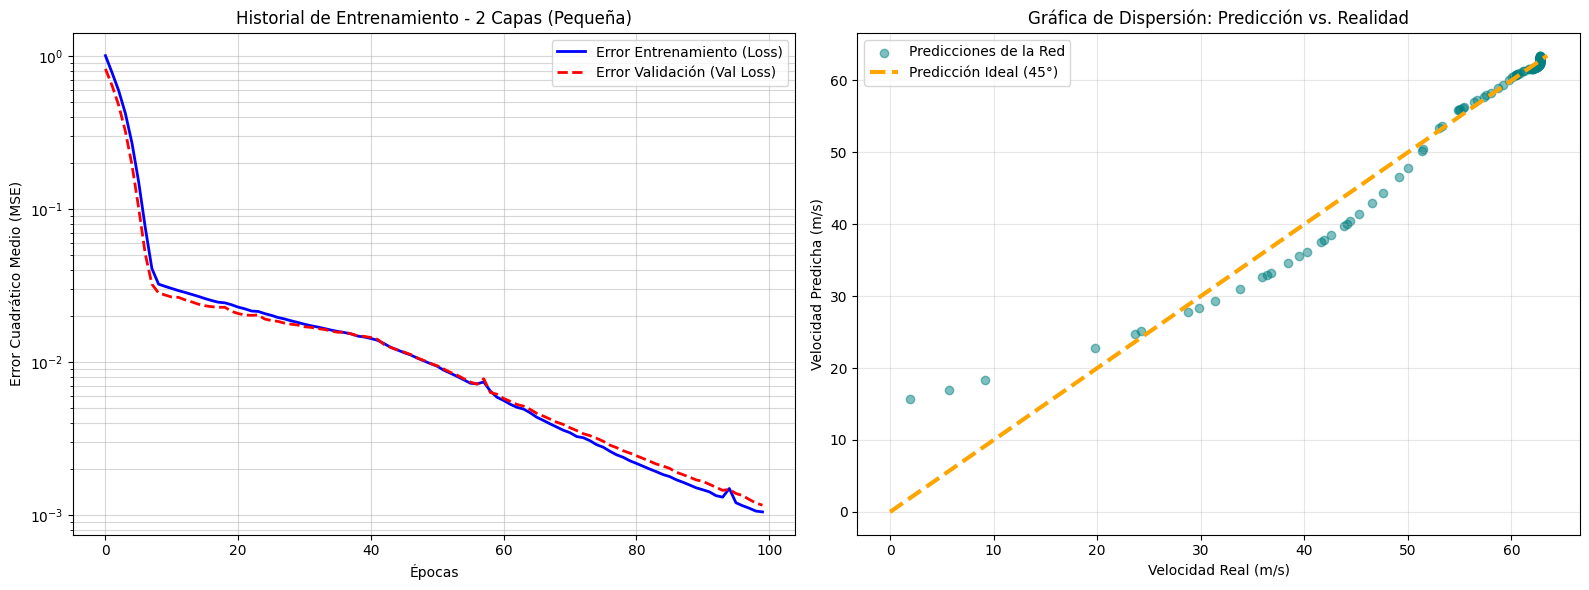

In [11]:
import matplotlib.pyplot as plt

# Seleccionamos uno de los modelos entrenados para el análisis detallado
# En este caso, el Modelo 2 (Mediana) suele ser el más equilibrado
modelo_a_graficar = modelos[0] 
nombre_modelo = nombres[0]
historial = historiales[0]

plt.figure(figsize=(16, 6))

# --- GRÁFICA 1: CURVAS DE APRENDIZAJE (LOSS) ---
plt.subplot(1, 2, 1)
plt.plot(historial.history['loss'], label='Error Entrenamiento (Loss)', color='blue', linewidth=2)
plt.plot(historial.history['val_loss'], label='Error Validación (Val Loss)', color='red', linestyle='--', linewidth=2)
plt.title(f'Historial de Entrenamiento - {nombre_modelo}')
plt.xlabel('Épocas')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.yscale('log') # Escala logarítmica para ver mejor la convergencia
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)

# --- GRÁFICA 2: DISPERSIÓN (PREDICCIÓN VS REALIDAD) ---
plt.subplot(1, 2, 2)

# Predicciones sobre el conjunto de prueba
y_pred_scaled = modelo_a_graficar.predict(X_test, verbose=0)

# Desnormalizamos para que los ejes tengan sentido físico (m/s)
y_real_inv = scaler_y.inverse_transform(y_test)
y_pred_inv = scaler_y.inverse_transform(y_pred_scaled)

# Dibujamos los puntos
plt.scatter(y_real_inv, y_pred_inv, alpha=0.5, color='teal', label='Predicciones de la Red')

# Dibujamos la línea de 45 grados (La predicción ideal)
lims = [0, max(y_real_inv.max(), y_pred_inv.max())]
plt.plot(lims, lims, color='orange', linestyle='--', linewidth=3, label='Predicción Ideal (45°)')

plt.title('Gráfica de Dispersión: Predicción vs. Realidad')
plt.xlabel('Velocidad Real (m/s)')
plt.ylabel('Velocidad Predicha (m/s)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

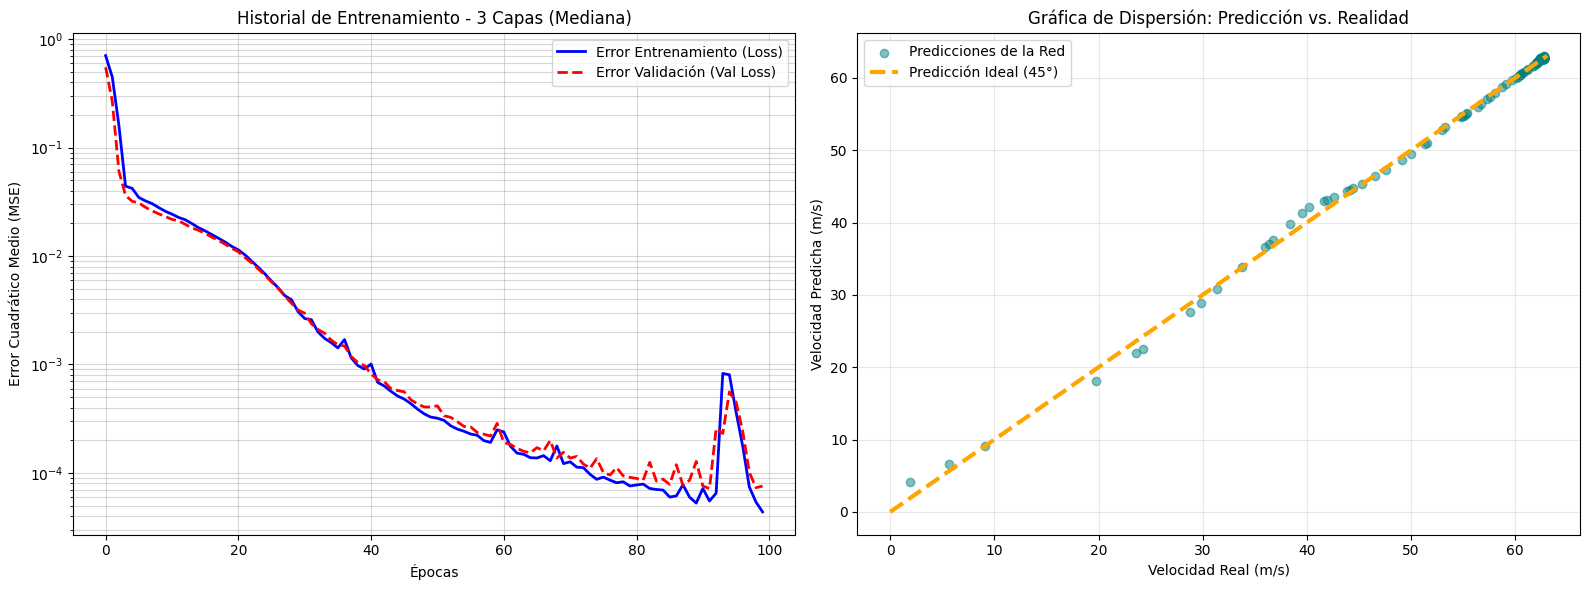

In [10]:
import matplotlib.pyplot as plt

# Seleccionamos uno de los modelos entrenados para el análisis detallado
# En este caso, el Modelo 2 (Mediana) suele ser el más equilibrado
modelo_a_graficar = modelos[1] 
nombre_modelo = nombres[1]
historial = historiales[1]

plt.figure(figsize=(16, 6))

# --- GRÁFICA 1: CURVAS DE APRENDIZAJE (LOSS) ---
plt.subplot(1, 2, 1)
plt.plot(historial.history['loss'], label='Error Entrenamiento (Loss)', color='blue', linewidth=2)
plt.plot(historial.history['val_loss'], label='Error Validación (Val Loss)', color='red', linestyle='--', linewidth=2)
plt.title(f'Historial de Entrenamiento - {nombre_modelo}')
plt.xlabel('Épocas')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.yscale('log') # Escala logarítmica para ver mejor la convergencia
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)

# --- GRÁFICA 2: DISPERSIÓN (PREDICCIÓN VS REALIDAD) ---
plt.subplot(1, 2, 2)

# Predicciones sobre el conjunto de prueba
y_pred_scaled = modelo_a_graficar.predict(X_test, verbose=0)

# Desnormalizamos para que los ejes tengan sentido físico (m/s)
y_real_inv = scaler_y.inverse_transform(y_test)
y_pred_inv = scaler_y.inverse_transform(y_pred_scaled)

# Dibujamos los puntos
plt.scatter(y_real_inv, y_pred_inv, alpha=0.5, color='teal', label='Predicciones de la Red')

# Dibujamos la línea de 45 grados (La predicción ideal)
lims = [0, max(y_real_inv.max(), y_pred_inv.max())]
plt.plot(lims, lims, color='orange', linestyle='--', linewidth=3, label='Predicción Ideal (45°)')

plt.title('Gráfica de Dispersión: Predicción vs. Realidad')
plt.xlabel('Velocidad Real (m/s)')
plt.ylabel('Velocidad Predicha (m/s)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

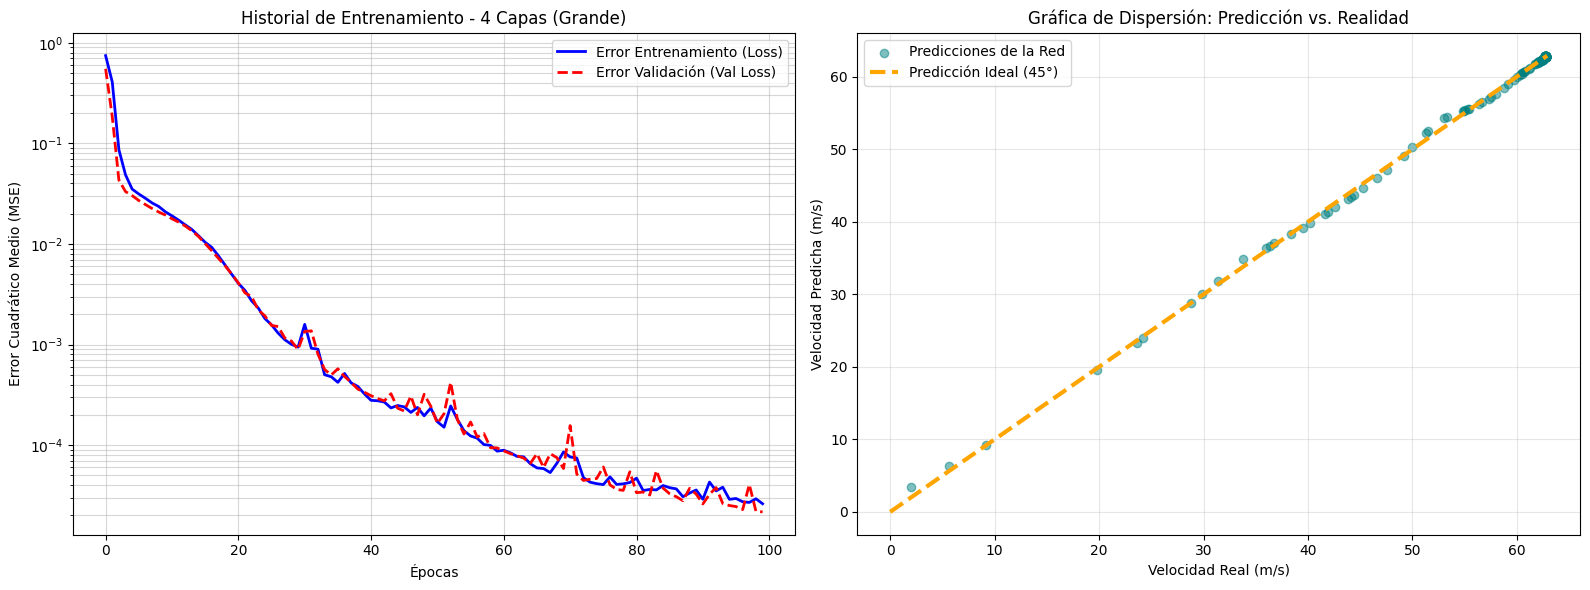

In [12]:
import matplotlib.pyplot as plt

# Seleccionamos uno de los modelos entrenados para el análisis detallado
# En este caso, el Modelo 2 (Mediana) suele ser el más equilibrado
modelo_a_graficar = modelos[2] 
nombre_modelo = nombres[2]
historial = historiales[2]

plt.figure(figsize=(16, 6))

# --- GRÁFICA 1: CURVAS DE APRENDIZAJE (LOSS) ---
plt.subplot(1, 2, 1)
plt.plot(historial.history['loss'], label='Error Entrenamiento (Loss)', color='blue', linewidth=2)
plt.plot(historial.history['val_loss'], label='Error Validación (Val Loss)', color='red', linestyle='--', linewidth=2)
plt.title(f'Historial de Entrenamiento - {nombre_modelo}')
plt.xlabel('Épocas')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.yscale('log') # Escala logarítmica para ver mejor la convergencia
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)

# --- GRÁFICA 2: DISPERSIÓN (PREDICCIÓN VS REALIDAD) ---
plt.subplot(1, 2, 2)

# Predicciones sobre el conjunto de prueba
y_pred_scaled = modelo_a_graficar.predict(X_test, verbose=0)

# Desnormalizamos para que los ejes tengan sentido físico (m/s)
y_real_inv = scaler_y.inverse_transform(y_test)
y_pred_inv = scaler_y.inverse_transform(y_pred_scaled)

# Dibujamos los puntos
plt.scatter(y_real_inv, y_pred_inv, alpha=0.5, color='teal', label='Predicciones de la Red')

# Dibujamos la línea de 45 grados (La predicción ideal)
lims = [0, max(y_real_inv.max(), y_pred_inv.max())]
plt.plot(lims, lims, color='orange', linestyle='--', linewidth=3, label='Predicción Ideal (45°)')

plt.title('Gráfica de Dispersión: Predicción vs. Realidad')
plt.xlabel('Velocidad Real (m/s)')
plt.ylabel('Velocidad Predicha (m/s)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

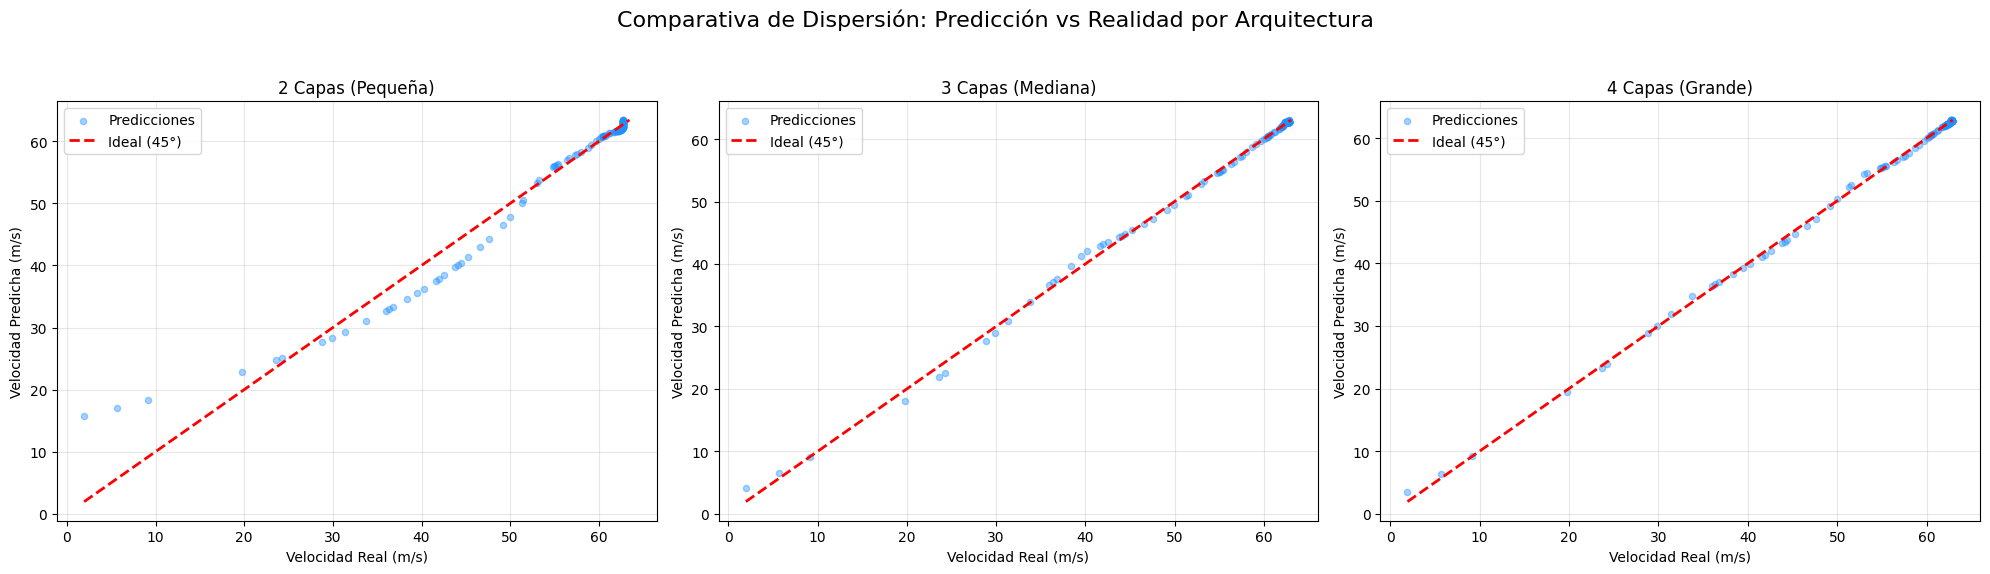

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Creamos una figura con 3 columnas
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Comparativa de Dispersión: Predicción vs Realidad por Arquitectura', fontsize=16)

# Preparar datos de prueba para la visualización
y_real_inv = scaler_y.inverse_transform(y_test)

for i in range(len(modelos)):
    # 1. Realizar predicción con el modelo actual
    y_pred_scaled = modelos[i].predict(X_test, verbose=0)
    y_pred_inv = scaler_y.inverse_transform(y_pred_scaled)
    
    # 2. Configurar la subtrama (ax)
    ax = axes[i]
    
    # Dibujar puntos de dispersión
    ax.scatter(y_real_inv, y_pred_inv, alpha=0.4, s=20, label='Predicciones', color='dodgerblue')
    
    # Dibujar línea ideal de 45 grados
    max_val = max(y_real_inv.max(), y_pred_inv.max())
    min_val = min(y_real_inv.min(), y_pred_inv.min())
    ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideal (45°)')
    
    # Personalización de cada gráfica
    ax.set_title(f'{nombres[i]}')
    ax.set_xlabel('Velocidad Real (m/s)')
    ax.set_ylabel('Velocidad Predicha (m/s)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 500 Epocas


In [14]:
# Definición de las 3 arquitecturas solicitadas
def obtener_modelos():
    # Arquitectura 1: 2 capas ocultas (Pequeña)
    m1 = keras.Sequential([
        layers.Dense(16, activation='relu', input_shape=(1,)),
        layers.Dense(16, activation='relu'),
        layers.Dense(1) # Salida lineal para regresión
    ])
    
    # Arquitectura 2: 3 capas ocultas (Mediana)
    m2 = keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=(1,)),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1)
    ])
    
    # Arquitectura 3: 4 capas ocultas (Grande/Profunda)
    m3 = keras.Sequential([
        layers.Dense(128, activation='relu', input_shape=(1,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1)
    ])
    
    modelos = [m1, m2, m3]
    nombres = ["2 Capas (Pequeña)", "3 Capas (Mediana)", "4 Capas (Grande)"]
    
    for m in modelos:
        m.compile(optimizer='adam', loss='mse', metrics=['mae'])
        
    return modelos, nombres

modelos, nombres = obtener_modelos()
historiales = []
tiempos = []

# Proceso de entrenamiento y medición de tiempo
for i in range(len(modelos)):
    print(f"Entrenando {nombres[i]}...")
    
    inicio = time.time()
    history = modelos[i].fit(
        X_train, y_train,
        epochs=500,
        batch_size=32,
        validation_split=0.2,
        verbose=0 # No mostramos logs para limpiar la salida
    )
    fin = time.time()
    
    duracion = fin - inicio
    tiempos.append(duracion)
    historiales.append(history)
    print(f"Completado en {duracion:.2f} segundos.")

print("\n--- Entrenamiento finalizado ---")

/home/sergio/Documentos/Tarea REdes Neuronales/tf_gpu/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entrenando 2 Capas (Pequeña)...
Completado en 38.16 segundos.
Entrenando 3 Capas (Mediana)...
Completado en 39.32 segundos.
Entrenando 4 Capas (Grande)...
Completado en 41.16 segundos.

--- Entrenamiento finalizado ---


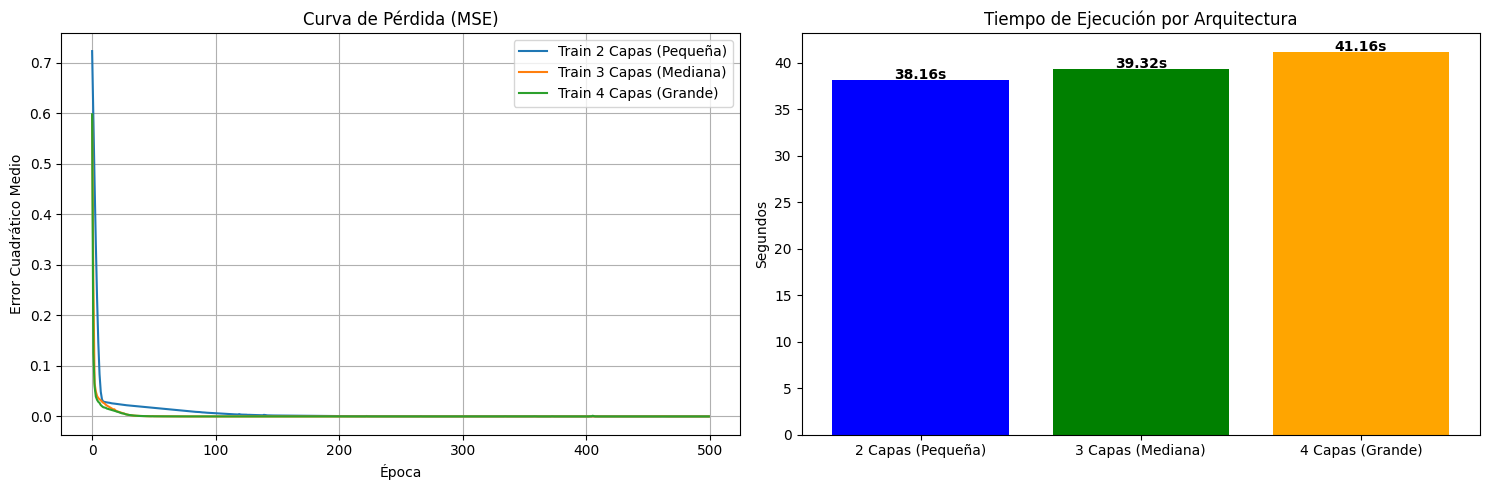

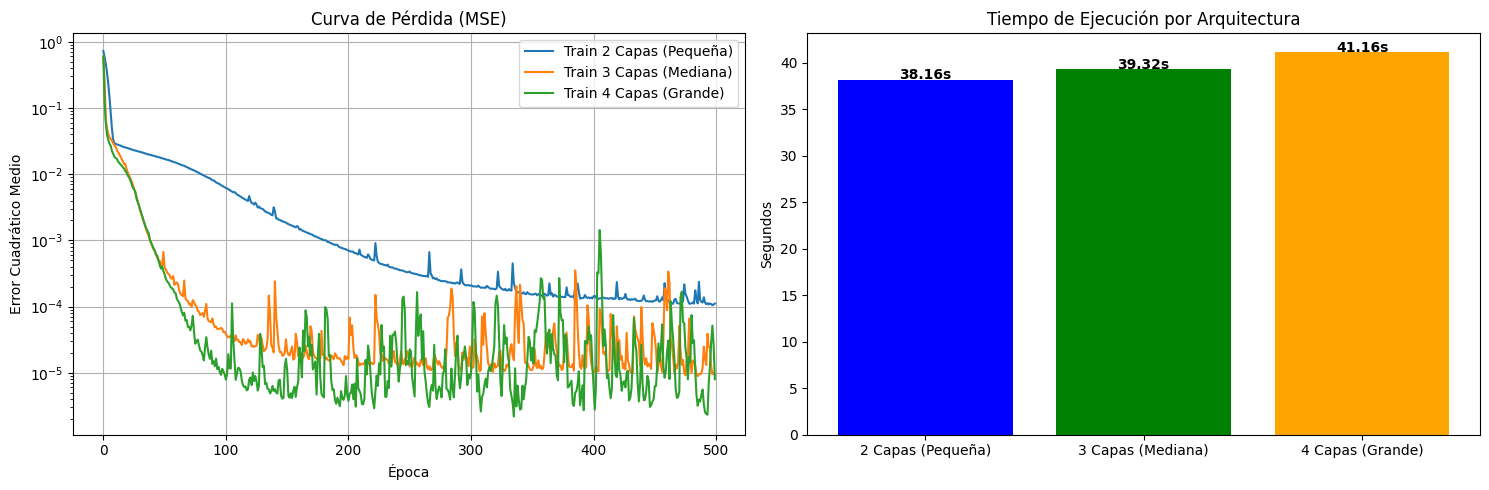

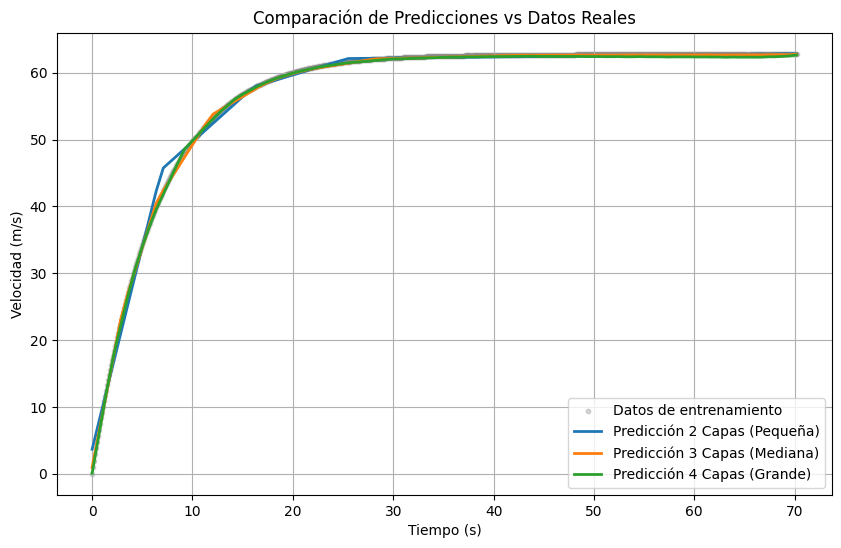

In [15]:
# Configuración de las gráficas
plt.figure(figsize=(15, 5))

# Gráfica 1: Pérdida (MSE) durante el entrenamiento
plt.subplot(1, 2, 1)
for i in range(len(historiales)):
    plt.plot(historiales[i].history['loss'], label=f'Train {nombres[i]}')
plt.title('Curva de Pérdida (MSE)')
plt.xlabel('Época')
plt.ylabel('Error Cuadrático Medio')
plt.legend()
plt.grid(True)

# Gráfica 2: Tiempos de ejecución
plt.subplot(1, 2, 2)
plt.bar(nombres, tiempos, color=['blue', 'green', 'orange'])
plt.title('Tiempo de Ejecución por Arquitectura')
plt.ylabel('Segundos')
for i, v in enumerate(tiempos):
    plt.text(i, v + 0.1, f"{v:.2f}s", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Configuración de las gráficas
plt.figure(figsize=(15, 5))

# Gráfica 1: Pérdida (MSE) durante el entrenamiento
plt.subplot(1, 2, 1)
for i in range(len(historiales)):
    plt.plot(historiales[i].history['loss'], label=f'Train {nombres[i]}')
plt.title('Curva de Pérdida (MSE)')
plt.xlabel('Época')
plt.ylabel('Error Cuadrático Medio')
plt.yscale('log') # Escala logarítmica para ver mejor la diferencia
plt.legend()
plt.grid(True)

# Gráfica 2: Tiempos de ejecución
plt.subplot(1, 2, 2)
plt.bar(nombres, tiempos, color=['blue', 'green', 'orange'])
plt.title('Tiempo de Ejecución por Arquitectura')
plt.ylabel('Segundos')
for i, v_val in enumerate(tiempos):
    plt.text(i, v_val + 0.05, f"{v_val:.2f}s", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# --- CORRECCIÓN DEL ERROR DE DIMENSIONES ---
# Aseguramos que usamos los mismos datos que entraron a la red
X_plot = np.linspace(min(t), max(t), 100).reshape(-1, 1)
# -------------------------------------------

# Gráfica de Predicciones Finales
plt.figure(figsize=(10, 6))

# Graficamos los datos originales (usando los arrays que cargamos en X e y para evitar el error de dimensión)
plt.scatter(scaler_X.inverse_transform(X_scaled), 
            scaler_y.inverse_transform(y_scaled), 
            color='gray', alpha=0.3, label='Datos de entrenamiento', s=10)

for i in range(len(modelos)):
    # Predecir sobre el rango completo de tiempo
    X_nuevo_scaled = scaler_X.transform(X_plot)
    y_pred_scaled = modelos[i].predict(X_nuevo_scaled, verbose=0)
    y_pred = scaler_y.inverse_transform(y_pred_scaled)
    
    plt.plot(X_plot, y_pred, label=f'Predicción {nombres[i]}', linewidth=2)

plt.title('Comparación de Predicciones vs Datos Reales')
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad (m/s)')
plt.legend()
plt.grid(True)
plt.show()

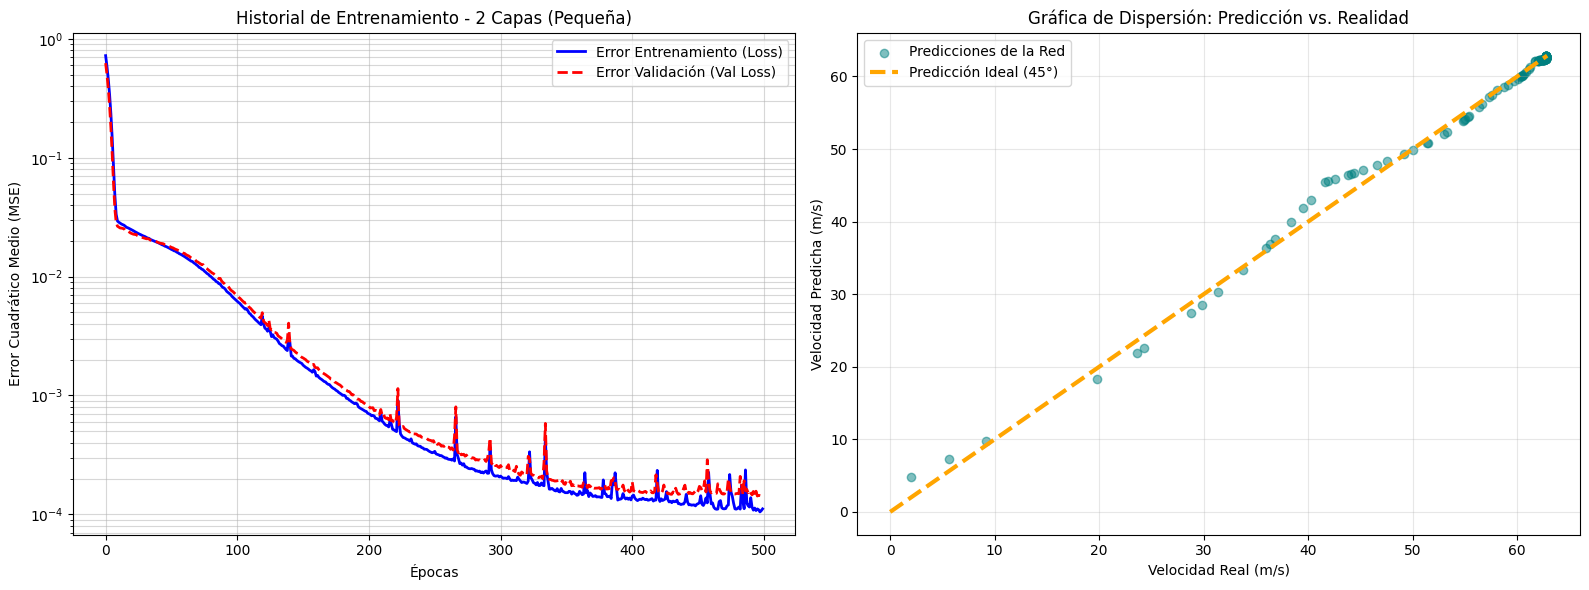

In [16]:
import matplotlib.pyplot as plt

# Seleccionamos uno de los modelos entrenados para el análisis detallado
# En este caso, el Modelo 2 (Mediana) suele ser el más equilibrado
modelo_a_graficar = modelos[0] 
nombre_modelo = nombres[0]
historial = historiales[0]

plt.figure(figsize=(16, 6))

# --- GRÁFICA 1: CURVAS DE APRENDIZAJE (LOSS) ---
plt.subplot(1, 2, 1)
plt.plot(historial.history['loss'], label='Error Entrenamiento (Loss)', color='blue', linewidth=2)
plt.plot(historial.history['val_loss'], label='Error Validación (Val Loss)', color='red', linestyle='--', linewidth=2)
plt.title(f'Historial de Entrenamiento - {nombre_modelo}')
plt.xlabel('Épocas')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.yscale('log') # Escala logarítmica para ver mejor la convergencia
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)

# --- GRÁFICA 2: DISPERSIÓN (PREDICCIÓN VS REALIDAD) ---
plt.subplot(1, 2, 2)

# Predicciones sobre el conjunto de prueba
y_pred_scaled = modelo_a_graficar.predict(X_test, verbose=0)

# Desnormalizamos para que los ejes tengan sentido físico (m/s)
y_real_inv = scaler_y.inverse_transform(y_test)
y_pred_inv = scaler_y.inverse_transform(y_pred_scaled)

# Dibujamos los puntos
plt.scatter(y_real_inv, y_pred_inv, alpha=0.5, color='teal', label='Predicciones de la Red')

# Dibujamos la línea de 45 grados (La predicción ideal)
lims = [0, max(y_real_inv.max(), y_pred_inv.max())]
plt.plot(lims, lims, color='orange', linestyle='--', linewidth=3, label='Predicción Ideal (45°)')

plt.title('Gráfica de Dispersión: Predicción vs. Realidad')
plt.xlabel('Velocidad Real (m/s)')
plt.ylabel('Velocidad Predicha (m/s)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

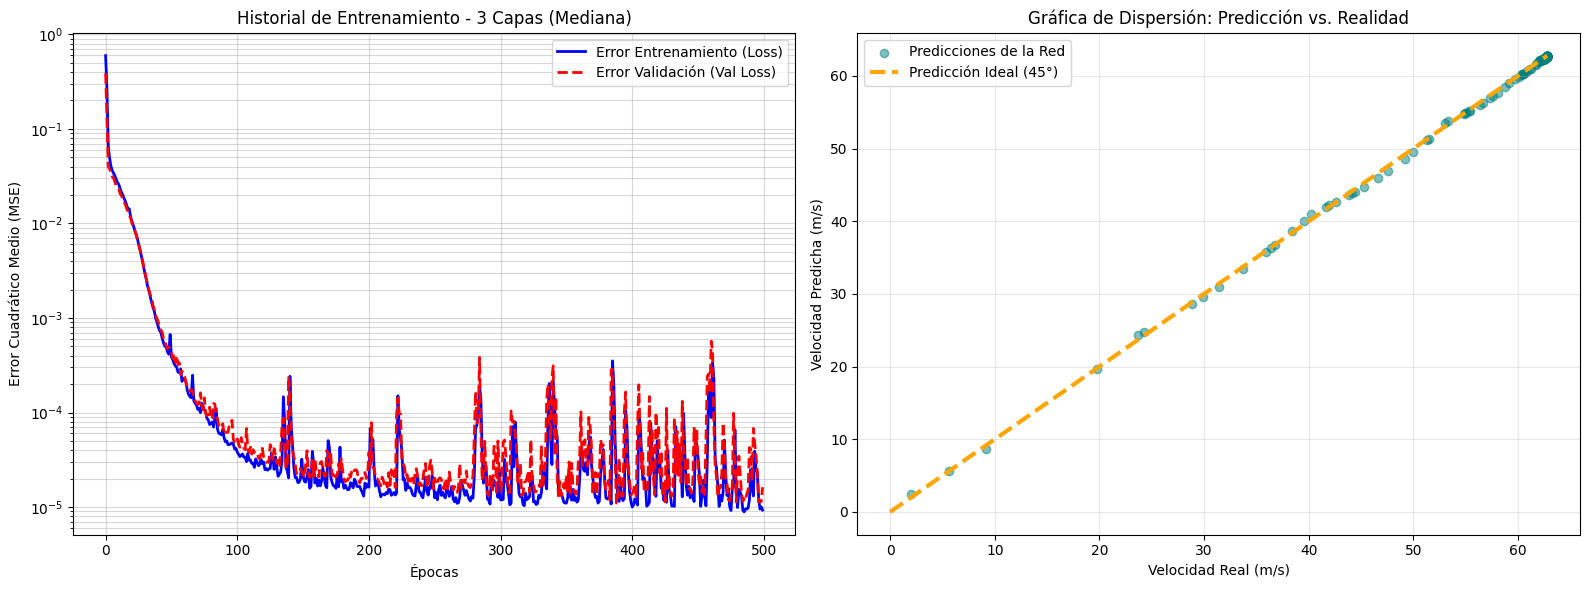

In [17]:
import matplotlib.pyplot as plt

# Seleccionamos uno de los modelos entrenados para el análisis detallado
# En este caso, el Modelo 2 (Mediana) suele ser el más equilibrado
modelo_a_graficar = modelos[1] 
nombre_modelo = nombres[1]
historial = historiales[1]

plt.figure(figsize=(16, 6))

# --- GRÁFICA 1: CURVAS DE APRENDIZAJE (LOSS) ---
plt.subplot(1, 2, 1)
plt.plot(historial.history['loss'], label='Error Entrenamiento (Loss)', color='blue', linewidth=2)
plt.plot(historial.history['val_loss'], label='Error Validación (Val Loss)', color='red', linestyle='--', linewidth=2)
plt.title(f'Historial de Entrenamiento - {nombre_modelo}')
plt.xlabel('Épocas')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.yscale('log') # Escala logarítmica para ver mejor la convergencia
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)

# --- GRÁFICA 2: DISPERSIÓN (PREDICCIÓN VS REALIDAD) ---
plt.subplot(1, 2, 2)

# Predicciones sobre el conjunto de prueba
y_pred_scaled = modelo_a_graficar.predict(X_test, verbose=0)

# Desnormalizamos para que los ejes tengan sentido físico (m/s)
y_real_inv = scaler_y.inverse_transform(y_test)
y_pred_inv = scaler_y.inverse_transform(y_pred_scaled)

# Dibujamos los puntos
plt.scatter(y_real_inv, y_pred_inv, alpha=0.5, color='teal', label='Predicciones de la Red')

# Dibujamos la línea de 45 grados (La predicción ideal)
lims = [0, max(y_real_inv.max(), y_pred_inv.max())]
plt.plot(lims, lims, color='orange', linestyle='--', linewidth=3, label='Predicción Ideal (45°)')

plt.title('Gráfica de Dispersión: Predicción vs. Realidad')
plt.xlabel('Velocidad Real (m/s)')
plt.ylabel('Velocidad Predicha (m/s)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

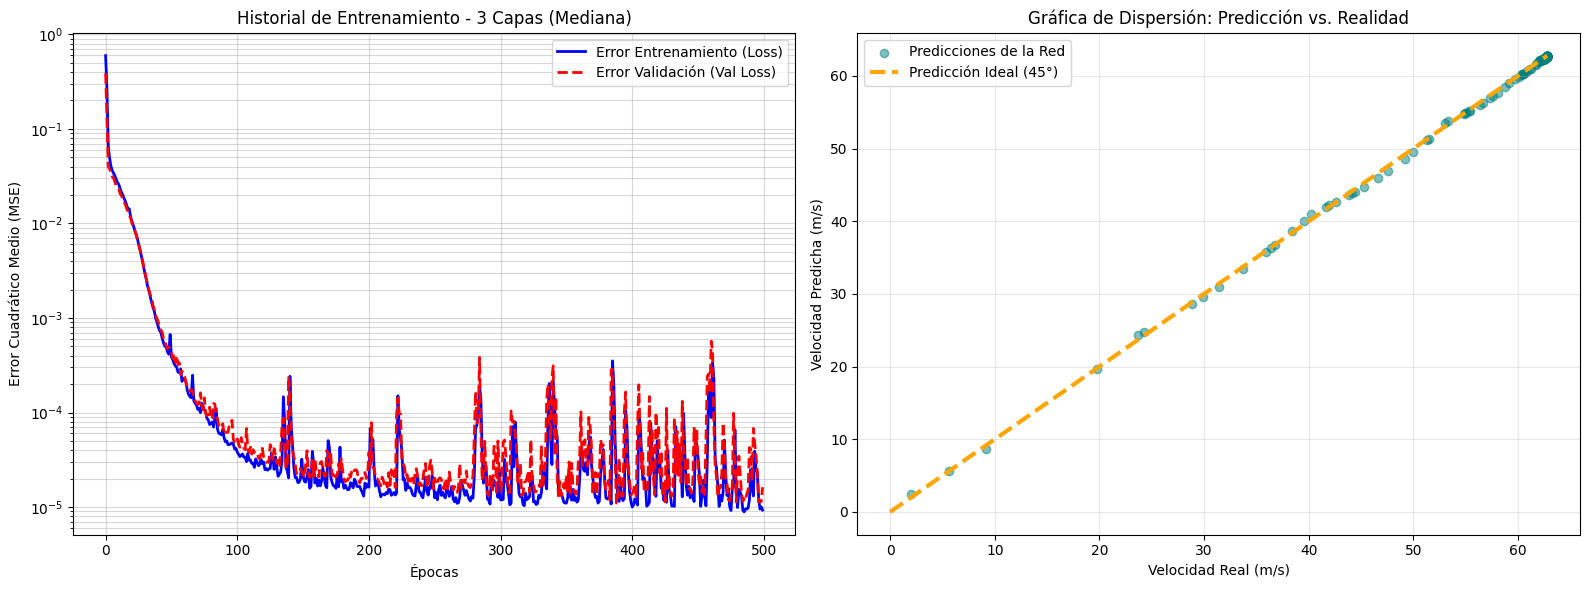

In [18]:
import matplotlib.pyplot as plt

# Seleccionamos uno de los modelos entrenados para el análisis detallado
# En este caso, el Modelo 2 (Mediana) suele ser el más equilibrado
modelo_a_graficar = modelos[1] 
nombre_modelo = nombres[1]
historial = historiales[1]

plt.figure(figsize=(16, 6))

# --- GRÁFICA 1: CURVAS DE APRENDIZAJE (LOSS) ---
plt.subplot(1, 2, 1)
plt.plot(historial.history['loss'], label='Error Entrenamiento (Loss)', color='blue', linewidth=2)
plt.plot(historial.history['val_loss'], label='Error Validación (Val Loss)', color='red', linestyle='--', linewidth=2)
plt.title(f'Historial de Entrenamiento - {nombre_modelo}')
plt.xlabel('Épocas')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.yscale('log') # Escala logarítmica para ver mejor la convergencia
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)

# --- GRÁFICA 2: DISPERSIÓN (PREDICCIÓN VS REALIDAD) ---
plt.subplot(1, 2, 2)

# Predicciones sobre el conjunto de prueba
y_pred_scaled = modelo_a_graficar.predict(X_test, verbose=0)

# Desnormalizamos para que los ejes tengan sentido físico (m/s)
y_real_inv = scaler_y.inverse_transform(y_test)
y_pred_inv = scaler_y.inverse_transform(y_pred_scaled)

# Dibujamos los puntos
plt.scatter(y_real_inv, y_pred_inv, alpha=0.5, color='teal', label='Predicciones de la Red')

# Dibujamos la línea de 45 grados (La predicción ideal)
lims = [0, max(y_real_inv.max(), y_pred_inv.max())]
plt.plot(lims, lims, color='orange', linestyle='--', linewidth=3, label='Predicción Ideal (45°)')

plt.title('Gráfica de Dispersión: Predicción vs. Realidad')
plt.xlabel('Velocidad Real (m/s)')
plt.ylabel('Velocidad Predicha (m/s)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

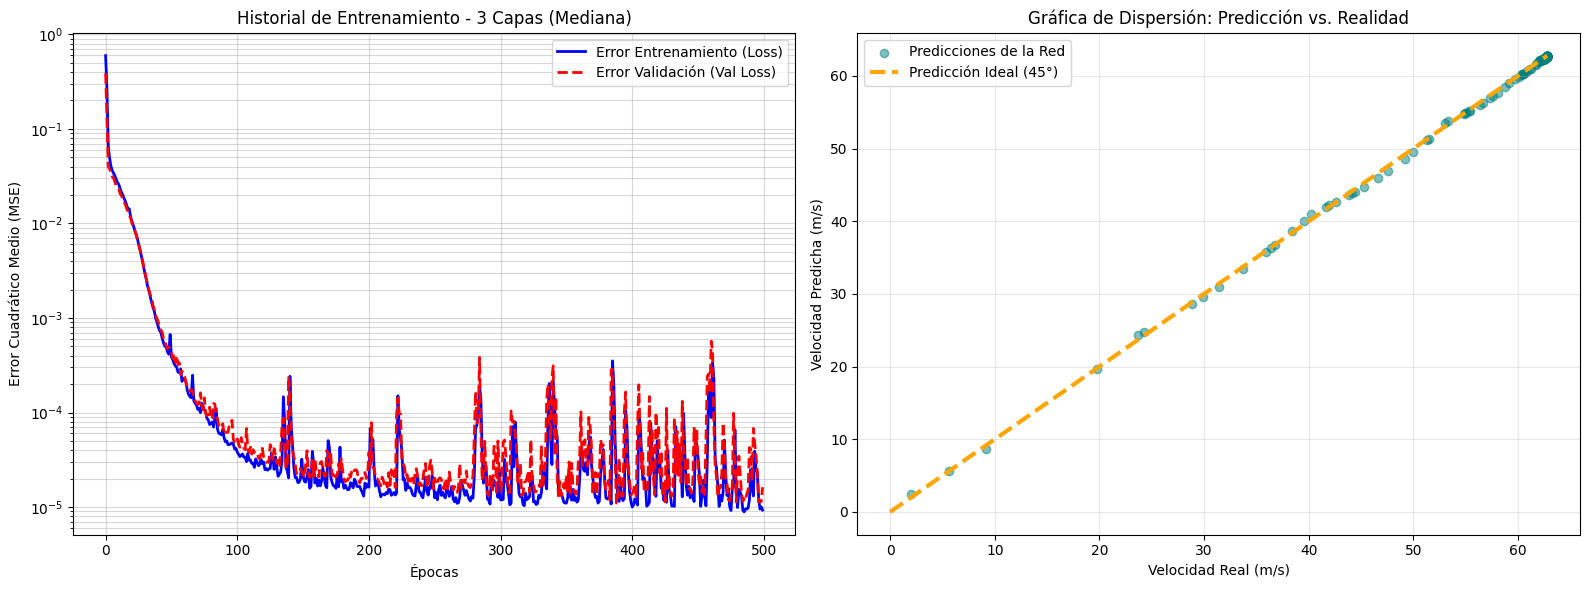

In [19]:
import matplotlib.pyplot as plt

# Seleccionamos uno de los modelos entrenados para el análisis detallado
# En este caso, el Modelo 2 (Mediana) suele ser el más equilibrado
modelo_a_graficar = modelos[1] 
nombre_modelo = nombres[1]
historial = historiales[1]

plt.figure(figsize=(16, 6))

# --- GRÁFICA 1: CURVAS DE APRENDIZAJE (LOSS) ---
plt.subplot(1, 2, 1)
plt.plot(historial.history['loss'], label='Error Entrenamiento (Loss)', color='blue', linewidth=2)
plt.plot(historial.history['val_loss'], label='Error Validación (Val Loss)', color='red', linestyle='--', linewidth=2)
plt.title(f'Historial de Entrenamiento - {nombre_modelo}')
plt.xlabel('Épocas')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.yscale('log') # Escala logarítmica para ver mejor la convergencia
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)

# --- GRÁFICA 2: DISPERSIÓN (PREDICCIÓN VS REALIDAD) ---
plt.subplot(1, 2, 2)

# Predicciones sobre el conjunto de prueba
y_pred_scaled = modelo_a_graficar.predict(X_test, verbose=0)

# Desnormalizamos para que los ejes tengan sentido físico (m/s)
y_real_inv = scaler_y.inverse_transform(y_test)
y_pred_inv = scaler_y.inverse_transform(y_pred_scaled)

# Dibujamos los puntos
plt.scatter(y_real_inv, y_pred_inv, alpha=0.5, color='teal', label='Predicciones de la Red')

# Dibujamos la línea de 45 grados (La predicción ideal)
lims = [0, max(y_real_inv.max(), y_pred_inv.max())]
plt.plot(lims, lims, color='orange', linestyle='--', linewidth=3, label='Predicción Ideal (45°)')

plt.title('Gráfica de Dispersión: Predicción vs. Realidad')
plt.xlabel('Velocidad Real (m/s)')
plt.ylabel('Velocidad Predicha (m/s)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()